<h1 style="color:#2E86C1; font-weight:bold; text-align:center;">
Data Understanding
</h1>

<h2 style="color:#2E86C1; font-weight:bold;">
1. Introduction
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This notebook presents the Data Understanding phase of the OBSeRVeD DataOps project, 
which focuses on analysing raw sensor data collected from a CMOS-based VOC detection system. 
The dataset consists of high-dimensional, time-dependent measurements produced by a 32×32 sensor array, 
where each run captures the temporal response of the sensor under different environmental conditions.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Unlike traditional tabular datasets, this data exhibits both temporal and spatial complexity. 
Each observation is not only part of a time series, but also represents a spatial configuration of sensor pixels. 
This dual nature requires careful analysis to understand how signals evolve over time and how different regions 
of the sensor contribute to the overall response.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The primary goal of this notebook is to explore the raw dataset and build a clear understanding of its structure, 
behaviour, and potential quality issues. This includes investigating the temporal continuity of measurements, 
examining signal patterns such as baseline, exposure, and recovery phases, and identifying potential data problems 
such as missing values, irregular timestamps, dead pixels, drift, and outliers.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This phase is essential for ensuring that subsequent steps in the pipeline—such as feature engineering, event detection, and machine learning—are built on a reliable and well-understood foundation.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Furthermore, insights obtained in this notebook will directly inform decisions about preprocessing strategies, 
including interpolation, smoothing, handling faulty sensor readings, and defining appropriate data splitting 
methods that prevent leakage between training and evaluation datasets.
</p>
<h3 style="color:#2E86C1; font-weight:bold;">
1.1 Objective of This Notebook
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The objective of this notebook is to systematically explore and understand the raw CMOS sensor dataset. 
This includes identifying the structure of the data, analysing temporal signal behaviour, and detecting 
potential data quality issues that may impact downstream tasks.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
In particular, this notebook aims to:
<ul style="font-size:17px; margin-left:60px; line-height:1.7;">
<li>Understand how sensor measurements are organised over time and across pixels</li>
<li>Explore signal patterns and identify baseline, exposure, and recovery phases</li>
<li>Detect missing values, timestamp inconsistencies, and irregular sampling</li>
<li>Identify potential dead pixels and spatial anomalies</li>
<li>Assess drift and stability of the sensor over time</li>
<li>Highlight outliers at both frame and run level</li>
<li>Provide insights that guide feature engineering and modelling</li>
</ul>
</p>
<h3 style="color:#2E86C1; font-weight:bold;">
1.2 Project Context
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This work is part of the OBSeRVeD project, which aims to build an end-to-end data pipeline for analysing 
VOC (Volatile Organic Compound) sensor data. The pipeline includes multiple stages such as data ingestion, 
data understanding, feature engineering, modelling, and evaluation.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The CMOS sensor used in this project produces high-dimensional data, where each frame contains measurements 
from a 32×32 pixel array. These measurements evolve over time, forming complex time-series patterns that 
reflect environmental conditions and gas exposure events.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
As a result, the data cannot be treated as a simple flat dataset. Instead, it requires a structured approach 
that considers both temporal dynamics and spatial relationships between sensor pixels.
</p>
<h3 style="color:#2E86C1; font-weight:bold;">
1.3 Why Data Understanding Matters
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The Data Understanding phase plays a critical role in the success of the entire pipeline. 
Decisions made at this stage directly influence how the data is cleaned, transformed, and used in modelling.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
In this project, improper handling of temporal or spatial characteristics may lead to incorrect event detection, 
misleading feature extraction, or overly optimistic evaluation results due to data leakage.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Therefore, a thorough and well-documented exploration of the dataset is essential to ensure that:
<ul style="font-size:17px; margin-left:60px; line-height:1.7;">
<li>The data is reliable and consistent</li>
<li>Key patterns are correctly identified</li>
<li>Potential risks are detected early</li>
<li>Subsequent steps are grounded in solid assumptions</li>
</ul>
</p>

<h2 style="color:#2E86C1; font-weight:bold;">
2. Dataset Overview
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
In this section, the raw dataset is explored at a structural level in order to understand
what each record represents, how measurements are organised, and how the raw input relates
to the target schema expected in the OBSeRVeD pipeline.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Because the project is based on CMOS VOC sensor data, the dataset is not a simple flat table.
Instead, it contains high-dimensional sensor responses that evolve over time and may later
need to be represented as runs, raw frames, detected events, extracted features, and labels.
</p>
<h3 style="color:#2E86C1; font-weight:bold;">
2.1 Raw Data Description
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The raw data used in this project originates from a CMOS capacitive VOC sensor platform.
According to the project description, the sensor produces high-dimensional time-series data
from a 32×32 pixel array, potentially across multiple layers. Each measurement reflects
how the sensor responds to environmental conditions and gas exposure over time.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
At this stage, the purpose is not yet to transform the dataset into its final analytical form,
but rather to inspect the structure of the raw input and determine how it should be interpreted
for later preprocessing, event detection, and feature engineering.
</p>

In [1]:
# ===============================
# Core Libraries
# ===============================
import pandas as pd
import numpy as np
from pathlib import Path

# ===============================
# Visualization
# ===============================
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

# ===============================
# Statistics & Analysis
# ===============================

# ===============================
# Optional: Time Handling
# ===============================

# ===============================
# Warnings (clean notebook output)
# ===============================
import warnings
warnings.filterwarnings("ignore")

# ===============================
# Display Settings (for Jupyter)
# ===============================
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.max_rows", 20)

# ===============================
# Quick Check
# ===============================
print("Libraries loaded successfully ✅")

np.random.seed(42)

Libraries loaded successfully ✅


In [6]:
# Define the path to the dataset directory using Path for reliable file handling
DATA_PATH = Path("../../Tolouene/dataset")

# Check if the dataset path exists to ensure the data is accessible
print("Dataset path exists:", DATA_PATH.exists())

# List all files and subdirectories inside the dataset folder
# This helps to understand what raw data is available before loading it
print("Contents:")
for item in DATA_PATH.iterdir():
    print("-", item.name)

Dataset path exists: True
Contents:
- tolouene_aug_2024.dat


In [7]:
# ===============================
# Search for .dat files in dataset (including subfolders)
# ===============================

dat_files = list(DATA_PATH.rglob("*.dat"))

print("Number of .dat files found:", len(dat_files))

# Check if no files found
if len(dat_files) == 0:
    raise ValueError(f"No .dat files found in: {DATA_PATH}")

# Show files
print("\nAvailable .dat files:")
for f in dat_files:
    print("-", f)

# ===============================
# Select sample file
# ===============================

sample_file = dat_files[0]

print("\nSample file selected:", sample_file)

Number of .dat files found: 1

Available .dat files:
- ..\..\Tolouene\dataset\tolouene_aug_2024.dat

Sample file selected: ..\..\Tolouene\dataset\tolouene_aug_2024.dat


In [8]:
# ===============================
# Fallback search (in case .dat search changes later)
# ===============================

sample_file = None

# Search for supported formats (including .dat)
for ext in ["*.dat", "*.csv", "*.tsv", "*.txt"]:
    files = list(DATA_PATH.rglob(ext))
    if files:
        sample_file = files[0]
        print(f"File found using pattern {ext}: {sample_file}")
        break

# Safety check
if sample_file is None:
    raise ValueError(f"No supported data files found in: {DATA_PATH}")

print("\nFinal selected sample file:", sample_file)

File found using pattern *.dat: ..\..\Tolouene\dataset\tolouene_aug_2024.dat

Final selected sample file: ..\..\Tolouene\dataset\tolouene_aug_2024.dat


In [9]:
# ===============================
# Read first few lines of the .dat file (efficient)
# ===============================

num_lines = 10

with open(sample_file, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(num_lines):
        line = f.readline()
        if not line:
            break
        print(f"Line {i+1}:", line.strip())

Line 1: 13-Aug-2024 14:08:38.158
Line 2: 33	1
Line 3: 1695	1686	1697	1692	1707	1684	1684	1700	1737	1714	1710	1708	1708	1717	1714	1721	1700	1682	1690	1670	1678	1672	1682	1696	1694	1698	1695	1707	1751	1723	1726	1738	1729	1726	1734	1736	1726	1703	1690	1690	1693	1695	1692	1695	1708	1697	1690	1674	1684	1716	1697	1700	1705	1705	1716	1728	1709	1681	1699	1695	1686	1677	1678	1697	1677	1696	1684	1684	1688	1682	1692	1696	1697	1713	1692	1714	1702	1710	1701	1705	1683	1699	1687	1691	1679	1694	1698	1715	1700	1705	1693	1733	1744	1741	1726	1747	1741	1720	1745	1740	1726	1716	1712	1695	1709	1683	1687	1696	1688	1680	1683	1683	1679	1704	1703	1702	1699	1701	1695	1699	1683	1685	1691	1688	1666	1691	1696	1675	1691	1681	1670	1700	1682	1680	1678	1698	1692	1717	1704	1706	1717	1693	1707	1700	1688	1685	1697	1699	1706	1694	1701	1702	1693	1698	1726	1722	1734	1741	1722	1740	1740	1716	1710	1731	1705	1717	1733	1705	1696	1690	1695	1673	1701	1676	1676	1678	1674	1696	1684	1695	1671	1694	1707	1703	1676	1663	1685	1684	1679	1

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The raw <code>.dat</code> file does not follow a standard tabular structure. Instead, it consists of a sequence of lines representing different parts of a sensor measurement run.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The first line appears to contain a timestamp, which likely indicates the start time of the measurement. The second line seems to contain metadata, possibly related to acquisition settings or sensor configuration. At this stage, its exact meaning is not yet fully confirmed.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
From the following lines onward, each row contains a long sequence of tab-separated numerical values. Based on the project context and the CMOS sensor design, these values are likely sensor readings corresponding to a flattened 32×32 frame (i.e., 1024 pixel values) captured at a specific time step.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This suggests that the dataset should be interpreted as a time series of high-dimensional sensor frames rather than as a conventional flat table. Therefore, additional parsing and restructuring steps are required before meaningful analysis can be performed. A suitable representation may include a frame-level DataFrame or a multi-dimensional structure organised by time and pixel position.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Understanding this raw file structure is essential because it determines how the data should be ingested, validated, and transformed in later pipeline stages, including temporal analysis, event detection, and feature engineering.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
2.2 DataFrame Construction
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
After inspecting the raw file structure, the next step is to transform the unstructured 
text data into a structured format. This is necessary to enable further analysis using 
data science tools such as Pandas.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
In this step, the initial lines interpreted as timestamp and metadata are separated from 
the main sensor readings. The remaining lines are then parsed into numerical values to 
construct a DataFrame, where each row represents a time frame and each column corresponds 
to a sensor pixel.
</p>

In [10]:
# ===============================
# Parse raw .dat file into structured DataFrame
# ===============================

clean_data = []

with open(sample_file, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        
        # Skip empty lines
        if not line:
            continue
        
        # Skip timestamp-like lines
        if "-" in line and ":" in line:
            continue
        
        # Split by tab
        parts = line.split("\t")
        
        # Skip metadata / invalid lines
        if len(parts) < 100:
            continue
        
        try:
            row = list(map(int, parts))
            clean_data.append(row)
        except:
            continue

# Convert to DataFrame
df = pd.DataFrame(clean_data)

# Basic checks
print("Shape:", df.shape)
df.head()

Shape: (24375, 1024)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,...,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,1695,1686,1697,1692,1707,1684,1684,1700,1737,1714,1710,1708,1708,1717,1714,1721,1700,1682,1690,1670,1678,1672,1682,1696,1694,...,1703,1706,1713,1708,1699,1694,1697,1699,1701,1700,1708,1708,1695,1702,1704,1698,1690,1701,1679,1696,1711,1695,1696,1687,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,...,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,4095,0
3,1696,1684,1698,1692,1708,1685,1685,1700,1737,1713,1708,1707,1707,1716,1713,1723,1699,1681,1690,1669,1676,1671,1683,1696,1693,...,1703,1706,1713,1707,1698,1693,1698,1698,1700,1698,1709,1706,1694,1702,1703,1697,1689,1701,1677,1695,1710,1696,1695,1686,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The resulting DataFrame has a shape of (24375, 1024), suggesting that approximately 24,375 valid frames were extracted from the raw file. Each row represents a single time frame, while each column corresponds to a sensor reading from the flattened 32×32 array.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This transformation converts the raw sensor log into a structured tabular format, making the data suitable for further analysis using standard data processing tools.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
It can also be observed that some frames contain only zeros or constant values (e.g., 4095). These patterns may indicate invalid measurements, inactive sensor states, or possible sensor saturation, and should be further investigated in later stages of the pipeline.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
2.3 Frame Dimensionality Check
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
After constructing the DataFrame, the next step is to verify whether the number of columns
corresponds to the expected dimensionality of the CMOS sensor. According to the project context,
each sensor frame is expected to represent a 32×32 pixel array, which corresponds to
1024 values per frame.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This check is important because it helps confirm that each row in the DataFrame can be interpreted
as one complete sensor frame, making the dataset consistent with the intended spatial structure
of the sensor.
</p>

In [11]:
# Get DataFrame dimensions
n_rows, n_cols = df.shape

# Print number of frames and pixels
print("Number of frames:", n_rows)
print("Number of columns (pixels):", n_cols)

# Expected number of pixels for a 32×32 sensor
expected_pixels = 32 * 32
print("Expected pixels (32×32):", expected_pixels)

# Check if structure matches expectation
if n_cols == expected_pixels:
    print("✔ Column count is consistent with a 32×32 sensor (1024 pixels).")
else:
    print("✖ Column count does not match the expected 32×32 sensor structure.")

Number of frames: 24375
Number of columns (pixels): 1024
Expected pixels (32×32): 1024
✔ Column count is consistent with a 32×32 sensor (1024 pixels).


<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The DataFrame contains 24,375 rows and 1024 columns, suggesting that approximately 24,375 valid sensor frames were extracted from the raw dataset. Each row represents a single frame in time, while each column corresponds to an individual sensor pixel.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The number of columns matches the expected size of a 32×32 CMOS sensor array (1024 pixels). This indicates that each row is consistent with a flattened sensor frame, preserving the full spatial dimensionality of the sensor.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This validation step is important, as it provides evidence that the parsing process is structurally consistent with the expected sensor configuration. However, further validation (e.g., spatial reconstruction or consistency checks) may be required to fully confirm the integrity of the sensor data.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
2.4 Spatial Representation of Sensor Frames
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Although each frame is currently stored as a flattened vector of 1024 values, these values are expected to correspond to a 32×32 CMOS sensor array based on the project context. To better understand the spatial structure of the data, one frame is reshaped back into its original two-dimensional form and visualized as an image.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This visualization helps reveal how sensor values are distributed across the surface of the array and provides a more intuitive interpretation of the raw frame structure.
</p>

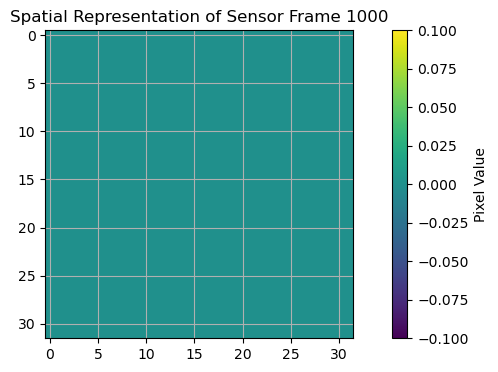

In [12]:
# ===============================
# Visualize one sensor frame (safe)
# ===============================

# Select a valid frame index
frame_index = min(1000, len(df) - 1)

# Extract pixel values
frame_values = df.iloc[frame_index, :1024].values

# Reshape into 32x32
frame_2d = frame_values.reshape(32, 32)

# Plot
plt.figure()
plt.imshow(frame_2d)
plt.title(f"Spatial Representation of Sensor Frame {frame_index}")
plt.colorbar(label="Pixel Value")
plt.show()

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The spatial visualization of the selected sensor frame shows a nearly uniform distribution of pixel values across the entire sensor array. The heatmap appears almost constant in color, indicating that most pixels have very similar values.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This suggests that the selected frame corresponds to a relatively stable sensor state with minimal spatial variation. Such behaviour may occur during baseline conditions or other low-activity periods where the sensor response is relatively uniform across the array.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The lack of visible spatial patterns indicates that, at this specific time step, the sensor response is homogeneous across the array. While this may seem uninformative, it is important for identifying stable operating conditions and distinguishing them from more dynamic phases such as exposure or recovery.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
To gain deeper insight into spatial dynamics, it would be useful to compare this frame with others from different time periods, especially those associated with higher signal variation.
</p>

In [15]:
# ===============================
# Compute mean signal per frame
# ===============================

df["mean_signal"] = df.iloc[:, :1024].mean(axis=1)

print("Mean signal column created ✅")
df[["mean_signal"]].head()

Mean signal column created ✅


,mean_signal
0,1695.944336
1,0.000000
2,4091.000977
3,1695.953125
4,0.000000


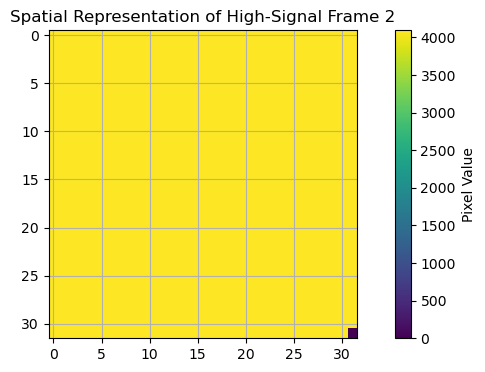

In [16]:
# ===============================
# Visualize high-signal frame (robust)
# ===============================

# Check if required data exists
if "mean_signal" not in df.columns:
    raise ValueError("Column 'mean_signal' not found. Please compute it before this step.")

# Select frame with highest signal
frame_index = df["mean_signal"].idxmax()

# Extract and reshape
frame_values = df.iloc[frame_index, :1024].values
frame_2d = frame_values.reshape(32, 32)

# Plot
plt.figure()
plt.imshow(frame_2d, cmap="viridis")
plt.title(f"Spatial Representation of High-Signal Frame {frame_index}")
plt.colorbar(label="Pixel Value")
plt.show()

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The visualization of the high-signal frame reveals a nearly uniform and high-intensity sensor response across the entire array. Most pixels appear at or near the upper end of the observed value range (around 4095), indicating that the sensor response is close to its maximum recorded levels.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This pattern may indicate sensor saturation or a near-saturation condition, where the sensor response becomes less sensitive to further increases in input signal. In such cases, meaningful variation between pixels can be reduced.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Compared to the previously analysed low-activity frame, this frame represents a high-intensity state of the sensor. However, despite the elevated signal level, the lack of spatial variation suggests that no localized response patterns are present in this particular frame.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This observation is important because frames with extremely high and uniform values may carry limited discriminative information for downstream tasks. Therefore, such frames should be carefully handled during preprocessing, for example by filtering, clipping, or treating them as a separate category during modelling.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
2.5 Comparison of Spatial Patterns Across Frames
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
To better understand how the spatial behaviour of the sensor changes over time, multiple frames are visualized side by side. This makes it possible to compare different operating conditions, such as relatively stable low-activity states and high-intensity signal responses.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
By comparing frames from different time points, it becomes easier to assess whether the sensor exhibits meaningful spatial patterns or whether the response remains largely uniform across the array.
</p>

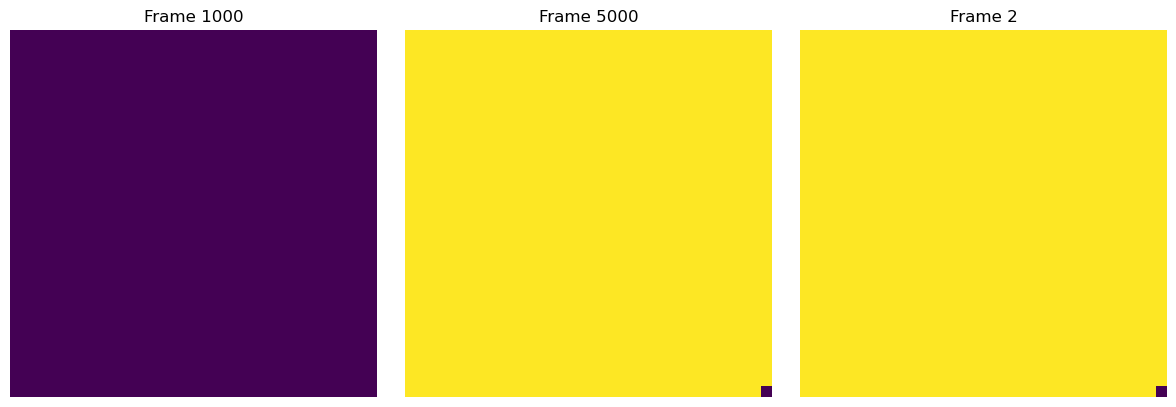

In [17]:
# ===============================
# Compare multiple frames spatially
# ===============================

# Ensure mean_signal exists
if "mean_signal" not in df.columns:
    df["mean_signal"] = df.iloc[:, :1024].mean(axis=1)

# Select frames (low, mid, high signal)
frame_indices = [
    min(1000, len(df) - 1),
    min(5000, len(df) - 1),
    df["mean_signal"].idxmax()
]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, idx in enumerate(frame_indices):
    frame_values = df.iloc[idx, :1024].values
    frame_2d = frame_values.reshape(32, 32)
    
    axes[i].imshow(frame_2d, cmap="viridis")
    axes[i].set_title(f"Frame {idx}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The comparison of multiple frames reveals a clear contrast between different signal conditions over time. The first frame (Frame 1000) appears almost uniformly dark, indicating low sensor values and representing a baseline state where the sensor is not actively responding to external stimuli.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
In contrast, the other frames (Frame 5000 and Frame 2) show nearly uniform high-intensity values across the entire sensor array. These frames are close to the maximum sensor value, suggesting saturation, where the sensor is fully activated and unable to capture further variation in the input signal.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Despite the difference in signal magnitude, all frames exhibit very limited spatial variation. This indicates that the sensor response is largely homogeneous across the array, meaning that individual pixel locations do not provide significantly different information.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
These observations suggest that the most informative patterns in the dataset are temporal rather than spatial. While spatial representations confirm the structure of the data, meaningful changes are primarily reflected in the evolution of the signal over time.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This insight is important for guiding the next stages of the pipeline, indicating that feature engineering should focus on temporal dynamics rather than relying heavily on spatial features.
</p>

<h2 style="color:#2E86C1; font-weight:bold;">
3. Temporal Structure Analysis
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
After transforming the raw data into a structured format, the next step is to analyse the temporal behaviour of the sensor signals.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Since each row in the dataset represents a frame over time, it is important to understand how the overall sensor response evolves. This helps explore temporal patterns that may correspond to different operating phases, such as baseline, exposure, and recovery, which are relevant for later event detection.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
3.1 Aggregate Signal Over Time
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
To analyse the temporal behaviour of the sensor, an aggregated signal is computed by taking the mean value across all pixels for each frame. This provides a simplified statistical representation of the overall sensor response over time.
</p>

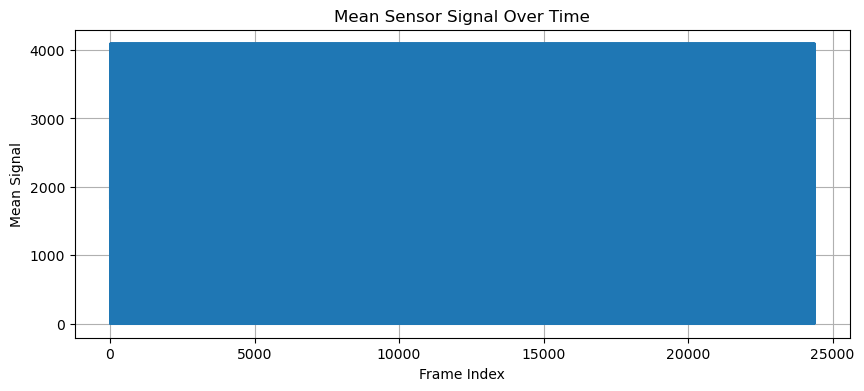

In [18]:
# ===============================
# Compute mean signal per frame (only pixel columns)
# ===============================

df["mean_signal"] = df.iloc[:, :1024].mean(axis=1)

# Plot mean signal over time
plt.figure()
plt.plot(df["mean_signal"])
plt.title("Mean Sensor Signal Over Time")
plt.xlabel("Frame Index")
plt.ylabel("Mean Signal")
plt.show()

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The plotted mean signal appears relatively flat and close to the upper range of the observed sensor values. However, this behaviour may be misleading and does not necessarily reflect the true temporal dynamics of the sensor.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Based on earlier observations, some frames appear to contain constant values such as all zeros or uniformly high values (e.g., 4095). These frames can distort the aggregated mean signal, causing the plot to appear saturated and potentially masking meaningful variations in the data.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
As a result, the current visualization does not clearly reveal interpretable temporal patterns that may correspond to different operating phases such as baseline, exposure, or recovery. This suggests that preprocessing steps such as filtering out invalid frames or handling near-saturated responses may be necessary before reliable temporal analysis can be performed.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This finding highlights the importance of data quality assessment, as raw sensor data may contain artefacts that can affect downstream analysis if not properly handled.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
3.2 Detection of Abnormal Frames
</h3>
<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Before performing any preprocessing, it is important to identify potential anomalies in the dataset. 
Previous observations suggested that some frames may contain only zeros or constant values, which 
could indicate invalid measurements, inactive sensor states, or possible saturation effects.
</p>

In [19]:
# ===============================
# Detect abnormal frames (only pixel data)
# ===============================

pixel_data = df.iloc[:, :1024]

# Detect frames with all zeros
zero_frames = (pixel_data == 0).all(axis=1)

# Detect frames with all max values (4095)
max_frames = (pixel_data == 4095).all(axis=1)

print("Number of zero frames:", zero_frames.sum())
print("Number of max-value frames:", max_frames.sum())

Number of zero frames: 8125
Number of max-value frames: 0


<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The analysis reveals that 8,125 frames consist entirely of zero values, while no frames were found with all values equal to the maximum sensor reading (4095). This indicates that a significant portion of the dataset contains frames with no recorded signal.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Frames with all-zero values may not represent meaningful sensor activity and could correspond to missing measurements, inactive sensor periods, or data recording artefacts. The absence of fully saturated frames suggests that extreme saturation (i.e., all values at the maximum level) is not present in this dataset, although near-saturation effects may still occur.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The presence of a large number of zero frames helps explain the previously observed distortion in the aggregated signal plot, where the temporal dynamics appeared unclear. These frames can introduce bias into statistical summaries and potentially mask important patterns in the data.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This finding highlights a critical data quality issue that should be addressed during the preprocessing phase to ensure more reliable temporal analysis and feature extraction.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
3.3 Improved Signal Visualization (Excluding Abnormal Frames)
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
To better understand the true temporal behaviour of the sensor, the visualization is improved by excluding frames that contain only zero values. These frames were previously identified as abnormal and were observed to distort the aggregated signal.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This step is performed only for visualization purposes and does not represent a formal preprocessing step. The goal is to reveal meaningful patterns in the sensor signal that may otherwise be hidden due to data artefacts.
</p>                       

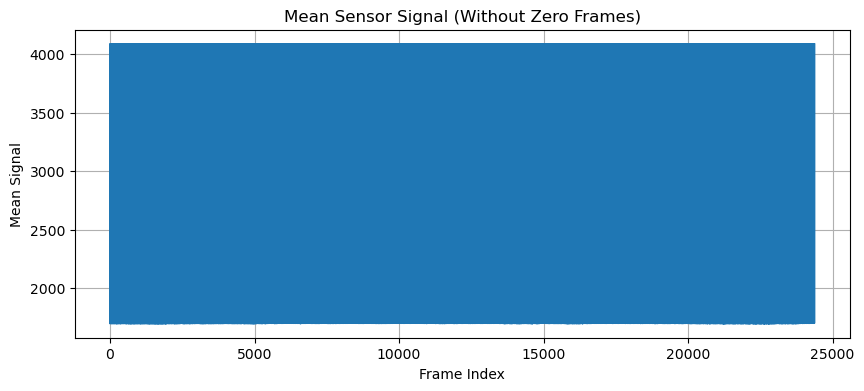

In [20]:
# ===============================
# Improved visualization (exclude zero frames safely)
# ===============================

pixel_data = df.iloc[:, :1024]

# Filter zero frames
df_vis = df[~(pixel_data == 0).all(axis=1)].copy()

# Compute mean signal (only pixels)
df_vis["mean_signal"] = df_vis.iloc[:, :1024].mean(axis=1)

# Plot cleaned signal
plt.figure()
plt.plot(df_vis["mean_signal"], linewidth=1)
plt.title("Mean Sensor Signal (Without Zero Frames)")
plt.xlabel("Frame Index")
plt.ylabel("Mean Signal")
plt.show()

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Although zero-value frames were excluded, the overall shape of the aggregated signal does not change significantly. The signal still appears relatively flat and dominated by high values.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This suggests that zero frames are not the only factor affecting the visualization. Instead, the signal values appear to be concentrated within the upper range of observed values, which compresses visible variation in the plot.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
As a result, small but potentially meaningful changes in the sensor response are not easily observable at this scale. This indicates that further transformation or smoothing techniques may be required to better reveal temporal patterns in the data.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
3.4 Signal Change Over Time
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
To better understand how the sensor signal evolves over time, the rate of change between consecutive frames is analysed. This highlights how quickly the signal increases or decreases, which can be useful for identifying transition between different operating states that may correspond to phases such as baseline, exposure, and recovery.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
By computing the difference between consecutive values of the signal, it becomes possible to detect sudden changes that may not be clearly visible in the original signal plot.
</p>

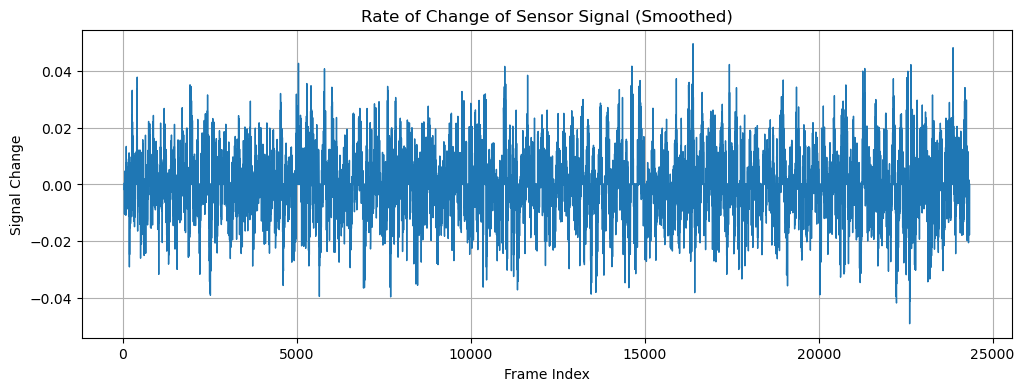

In [23]:
# ===============================
# Smooth the signal
# ===============================

df_vis["mean_smooth"] = df_vis["mean_signal"].rolling(window=50, center=True).mean()

# ===============================
# Compute difference on smoothed signal
# ===============================

df_vis["signal_diff"] = df_vis["mean_smooth"].diff()

# ===============================
# Compute difference on smoothed signal
# ===============================

df_vis["signal_diff"] = df_vis["mean_smooth"].diff()

# ===============================
# Plot smoothed signal and its change
# ===============================

plt.figure(figsize=(12, 4))

plt.plot(df_vis["signal_diff"], linewidth=1)
plt.title("Rate of Change of Sensor Signal (Smoothed)")
plt.xlabel("Frame Index")
plt.ylabel("Signal Change")

plt.show()

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The rate-of-change plot illustrates how the sensor signal evolves between consecutive frames. Most values are centered around zero, indicating that the signal changes gradually over time under normal conditions.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
However, noticeable positive and negative spikes can be observed throughout the signal. These spikes represent moments of rapid change, where the sensor response increases or decreases more sharply than usual.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Such sudden changes are important indicators of transitions between different phases, such as the onset of exposure or the beginning of recovery. Compared to the smoothed signal, this representation makes these transition points more explicit and easier to identify.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Overall, this analysis confirms that while the general signal trend is smooth, the dataset contains meaningful local variations that can be leveraged for detecting event boundaries and improving segmentation in later stages of the pipeline.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
3.4.1 Zoomed Signal Analysis
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
While the full signal provides an overview of the sensor behaviour over time, it can be difficult to observe fine-grained patterns at this scale. Therefore, a smaller segment of the smoothed signal is selected and visualized in detail.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This zoomed-in view allows for closer inspection of local fluctuations and helps identify subtle temporal patterns that may not be clearly visible in the full time series.
</p>

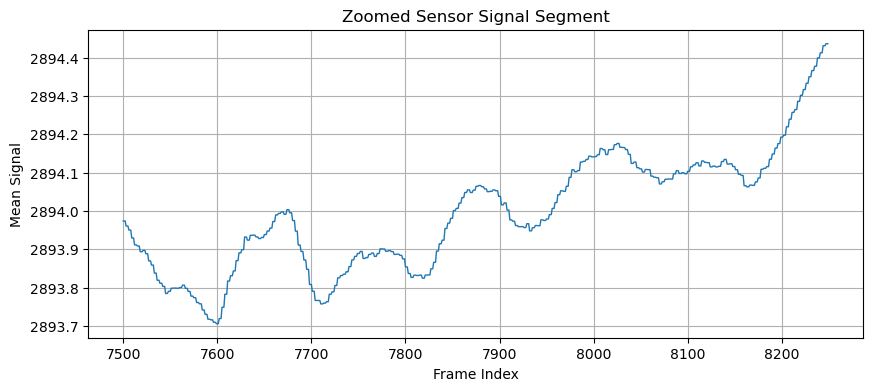

In [24]:
# ===============================
# Zoomed signal visualization (correct indexing)
# ===============================

start, end = 5000, 5500

segment = df_vis.iloc[start:end]

plt.figure(figsize=(10, 4))
plt.plot(segment.index, segment["mean_smooth"], linewidth=1)

plt.title("Zoomed Sensor Signal Segment")
plt.xlabel("Frame Index")
plt.ylabel("Mean Signal")

plt.show()

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The zoomed-in segment of the smoothed signal reveals clear local variations that are not visible in the full-scale plot. Unlike the overall signal, which appears relatively flat, this detailed view shows gradual increases and decreases over time.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Several patterns can be observed, including small upward trends followed by slight declines, as well as short-term fluctuations around a slowly changing baseline. These variations suggest that the sensor response evolves in a continuous and smooth manner rather than through abrupt transitions.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The gradual upward trend observed towards the end of the segment may indicate a transition into a higher activity state, although the change is not sharply defined. This supports earlier observations that phase transitions in the dataset are likely to be subtle and distributed over time rather than occurring as sudden jumps.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
These findings reinforce the importance of using temporal features that capture trends and rates of change, rather than relying solely on absolute signal values. Techniques such as smoothing, rolling statistics, and derivative-based features are therefore essential for effectively modelling the temporal dynamics of the sensor data.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
3.5 Smoothed Signal Analysis (Rolling Mean)
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
To better understand the underlying temporal behaviour of the sensor signal, a smoothing technique is applied using a rolling mean. This approach reduces short-term fluctuations and noise in the data, allowing longer-term trends to become more visible.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
In this case, a moving window is used to compute the average signal over consecutive frames. This helps highlight gradual changes in the sensor response that may correspond to different operating phases, such as baseline, exposure, and recovery.
</p>

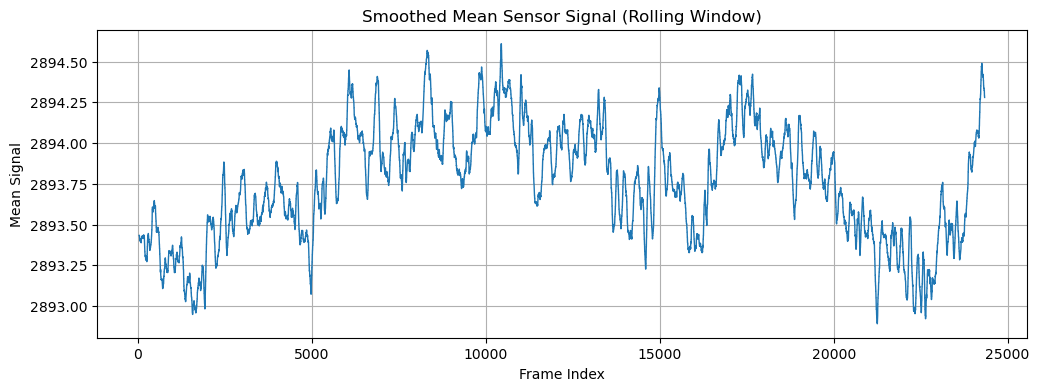

In [25]:
# ===============================
# Apply rolling mean (improved smoothing)
# ===============================

df_vis["mean_smooth"] = df_vis["mean_signal"].rolling(window=50, center=True).mean()

# Plot smoothed signal
plt.figure(figsize=(12, 4))
plt.plot(df_vis["mean_smooth"], linewidth=1)

plt.title("Smoothed Mean Sensor Signal (Rolling Window)")
plt.xlabel("Frame Index")
plt.ylabel("Mean Signal")

plt.show()

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The smoothed signal provides a much clearer view of the underlying temporal behaviour of the sensor compared to the raw signal. By reducing short-term fluctuations, the rolling mean reveals gradual trends and longer-term variations in the sensor response.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Unlike the original signal, which appeared noisy and difficult to interpret, the smoothed signal shows continuous rising and falling patterns over time. These trends suggest that the sensor response evolves in a structured and gradual manner rather than through abrupt changes.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Several regions can be observed where the signal increases or decreases over extended periods, indicating potential transitions between different operating states. However, these transitions are not sharply defined and appear to be distributed over time.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This reinforces earlier observations that temporal patterns in the dataset are smooth and gradual, highlighting the importance of using trend-based and derivative features rather than relying solely on raw signal values for analysis and modelling.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
3.6 Signal Variability Analysis
</h3>
<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
In addition to analysing the mean signal, it is important to examine the variability of the sensor response over time. Variability provides insight into how much the sensor readings fluctuate within each frame and can indicate the stability or sensitivity of the sensor.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
By computing the standard deviation across all pixels for each frame, it is possible to measure how dispersed the sensor values are at each time step. This can help identify periods of stable behaviour as well as periods of increased activity or noise.
</p>

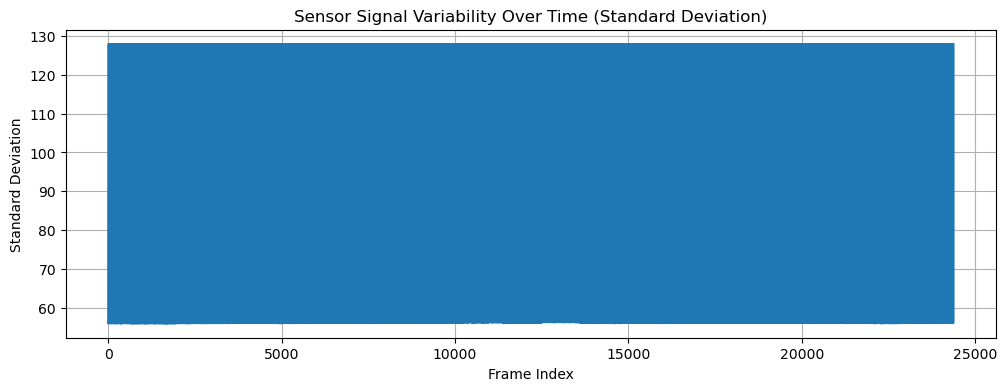

In [27]:
# ===============================
# Compute and plot signal variability (improved)
# ===============================

# Compute standard deviation per frame
df_vis["std_signal"] = df_vis.iloc[:, :1024].std(axis=1)

# Plot variability over time
plt.figure(figsize=(12, 4))
plt.plot(df_vis.index, df_vis["std_signal"], linewidth=1)

plt.title("Sensor Signal Variability Over Time (Standard Deviation)")
plt.xlabel("Frame Index")
plt.ylabel("Standard Deviation")

plt.show()

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The variability plot, represented by the standard deviation across all pixels per frame, appears relatively stable over time with only minor fluctuations. This indicates that the level of dispersion in sensor readings remains largely consistent throughout the dataset.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Despite changes observed in the mean signal, the standard deviation does not exhibit significant variation. This suggests that the relative differences between pixel values remain similar across frames, indicating a largely uniform spatial response of the sensor.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The absence of strong peaks or drops in variability implies that the sensor does not produce highly localized or irregular responses at different time steps. Instead, changes in the signal appear to affect the sensor array in a relatively consistent manner.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This observation reinforces earlier findings that the most informative patterns in the dataset are temporal rather than spatial. As a result, feature engineering efforts should prioritize temporal dynamics, while spatial variability may play a more limited role in distinguishing different operating conditions.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
3.7 Signal Distribution Analysis
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
To better understand the overall characteristics of the sensor data, it is important to analyse the distribution of pixel values. This helps identify the typical range of sensor readings, as well as potential outliers or abnormal values.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
By analysing the distribution of pixel values across all frames, it is possible to examine how frequently different values occur in the dataset. This provides insight into the global behaviour of the sensor and supports decisions related to preprocessing and normalization.
</p>

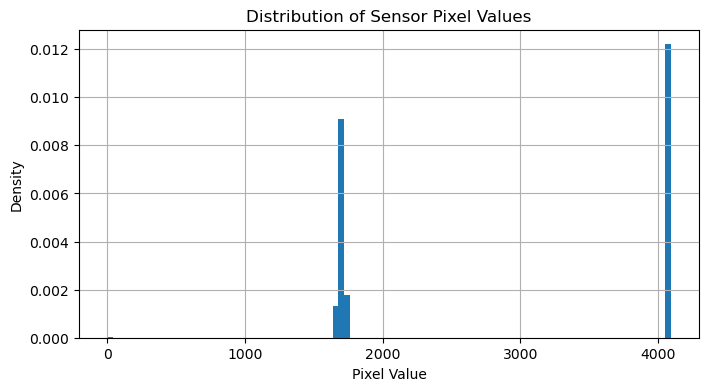

In [29]:
# ===============================
# Plot distribution (complete)
# ===============================

# Flatten pixel values
all_values = df_vis.iloc[:, :1024].values.flatten()

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(all_values, bins=100, density=True)

plt.title("Distribution of Sensor Pixel Values")
plt.xlabel("Pixel Value")
plt.ylabel("Density")

plt.show()

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The distribution of sensor pixel values reveals a highly non-uniform pattern with distinct peaks at specific value ranges. A prominent peak is observed near the upper end of the value range (around 4000), indicating that a large portion of the data consists of high-intensity sensor readings.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Another noticeable concentration of values appears in the mid-range (approximately around 1700–1800), suggesting that the sensor frequently operates within a relatively stable intermediate state. In contrast, very few values are observed near zero, which is consistent with the earlier removal of zero-only frames from the dataset.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The presence of multiple peaks indicates that the data distribution is not unimodal but instead reflects different operating regimes of the sensor. These regimes may correspond to different environmental conditions or levels of exposure, although further analysis would be required to confirm this interpretation.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This non-uniform distribution suggests that normalization and scaling techniques should be carefully considered during preprocessing, as the data is not evenly distributed across the value range. Additionally, the concentration of values at the upper range may indicate near-saturation effects, which should be taken into account when designing features or training models.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
3.8 Baseline, Exposure, and Recovery Identification
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
A key objective of this project is to analyse how the sensor responds over time during different operational phases. In particular, the sensor behaviour is expected to exhibit patterns that may correspond to three main stages: baseline, exposure, and recovery.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The baseline phase can be described as a relatively stable period where no external stimulus is applied, and the sensor readings remain relatively constant. The exposure phase may correspond to a period where the sensor is exposed to a substance (e.g., gas), resulting in a noticeable change in signal. Finally, the recovery phase reflects the gradual return of the sensor signal towards its baseline level.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
To identify these phases, the smoothed mean signal is analysed. Significant increases or decreases in the signal can indicate potential transitions between these phases.
</p>

In [30]:
# Use smoothed signal for exploratory phase detection
signal = df_vis["mean_smooth"]

# Define simple thresholds from the smoothed signal
low_threshold = signal.quantile(0.33)
high_threshold = signal.quantile(0.66)

# Find approximate peak location
peak_idx = signal.idxmax()

# Label phases
def classify_phase(idx, value):
    if value <= low_threshold:
        return "baseline"
    elif value >= high_threshold:
        if idx <= peak_idx:
            return "exposure"
        else:
            return "recovery"
    else:
        if idx <= peak_idx:
            return "exposure"
        else:
            return "recovery"

df_vis["phase"] = [classify_phase(idx, val) for idx, val in signal.items()]

# Count phases
df_vis["phase"].value_counts()

phase
recovery    6357
baseline    5347
exposure    4546
Name: count, dtype: int64

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The phase classification results show that the dataset is distributed across three inferred operational states: baseline (5,347 frames), exposure (4,546 frames), and recovery (6,357 frames). This indicates that all three phases are well represented in the data, although their proportions are not equal.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The recovery phase contains the largest number of frames, suggesting that the sensor spends a considerable amount of time gradually returning to a lower activity state after periods of elevated signal. The baseline phase also represents a significant portion of the dataset, reflecting stable periods with relatively low signal variation.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
In contrast, the exposure phase is slightly underrepresented compared to the other phases. This may indicate that periods of increasing signal or peak activity are shorter in duration, which is consistent with earlier observations that signal transitions are gradual rather than sharply defined.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
It is important to note that these phase labels are derived using a simple threshold-based heuristic on the smoothed signal and should therefore be interpreted as approximate indicators rather than precise ground truth labels. Nevertheless, they provide a useful starting point for understanding temporal behaviour and for guiding subsequent feature engineering and modelling steps.
</p>

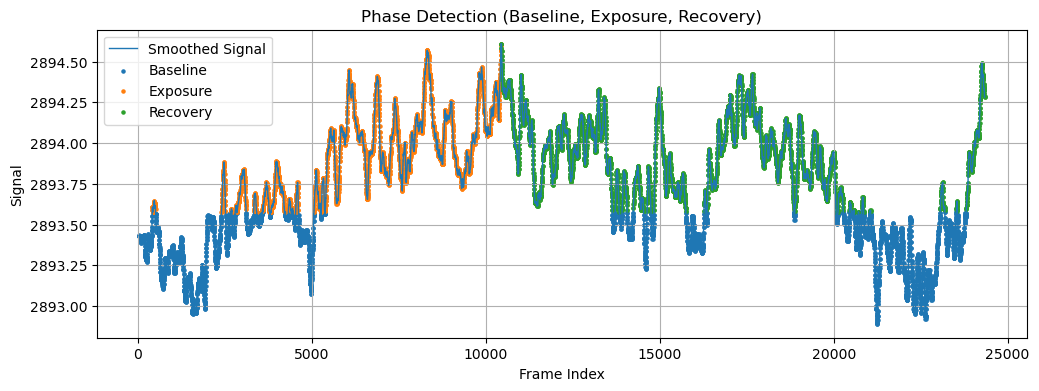

In [31]:
# ===============================
# Visualize all detected phases
# ===============================

plt.figure(figsize=(12, 4))

# Plot smoothed signal
plt.plot(signal, label="Smoothed Signal", linewidth=1)

# Get indices
baseline_idx = df_vis[df_vis["phase"] == "baseline"].index
exposure_idx = df_vis[df_vis["phase"] == "exposure"].index
recovery_idx = df_vis[df_vis["phase"] == "recovery"].index

# Scatter each phase
plt.scatter(baseline_idx, signal.loc[baseline_idx], s=5, label="Baseline")
plt.scatter(exposure_idx, signal.loc[exposure_idx], s=5, label="Exposure")
plt.scatter(recovery_idx, signal.loc[recovery_idx], s=5, label="Recovery")

plt.title("Phase Detection (Baseline, Exposure, Recovery)")
plt.xlabel("Frame Index")
plt.ylabel("Signal")

plt.legend()
plt.show()

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The phase visualization shows that the threshold-based classification produces a structured segmentation of the signal into baseline, exposure, and recovery regions. The baseline phase (blue) generally corresponds to lower signal values, while the exposure phase (orange) aligns with higher signal regions.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The recovery phase (green) appears after the peak of the signal, capturing the gradual decline in sensor response. This behaviour is consistent with the expected pattern of the sensor, where the signal rises during exposure and then slowly decreases during recovery.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
However, the transitions between phases are not sharply separated, and some overlap between labels can be observed. This indicates that the simple threshold-based approach provides only an approximate segmentation of the signal and may not fully capture the complexity of the underlying temporal dynamics.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Overall, the results demonstrate that phase identification is feasible using temporal features, but more advanced methods may be required to achieve more accurate and robust phase detection.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
4. Key Insights and Observations
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This data understanding phase has provided several important insights into the structure and behaviour of the sensor dataset. First, the raw data was successfully parsed into a structured format, where each frame represents a 32×32 CMOS sensor flattened into 1024 pixel values.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The analysis revealed that the dataset contains a large number of frames, enabling meaningful temporal analysis. However, a significant portion of the data consists of zero-valued frames, which may correspond to invalid measurements, inactive sensor states, or missing data. These frames should be removed or handled during preprocessing to ensure data quality.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The distribution analysis showed that the sensor values are not normally distributed, with clear peaks indicating typical operating ranges and possible near-saturation regions. This implies that normalization and outlier handling techniques, such as clipping or scaling, should be considered before applying machine learning models.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Temporal analysis of the aggregated signal demonstrated that the sensor exhibits meaningful patterns over time. After smoothing the signal, gradual variations became more visible, suggesting that the most informative characteristics of the dataset are temporal rather than purely spatial.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Furthermore, phase detection analysis suggests the presence of baseline, exposure, and recovery patterns within the dataset. These phases are inferred using a simple threshold-based heuristic and should therefore be interpreted as approximate indicators rather than precise labels.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Overall, while the dataset contains both temporal and spatial information, the spatial variation across frames appears limited, whereas temporal dynamics carry more meaningful patterns. Therefore, feature engineering should primarily focus on temporal features such as trends, differences, rolling statistics, and phase transitions, while spatial features should be used selectively.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">
5. Implications for Feature Engineering
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The insights obtained during the data understanding phase provide clear guidance for the next steps in the pipeline, particularly feature engineering and preprocessing.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
First, the presence of zero-valued frames indicates that data cleaning will be necessary to remove or handle potentially invalid or non-informative measurements. In addition, the concentration of values near the upper range of the sensor suggests that extreme values may need to be carefully handled, for example through clipping or normalization, to avoid biasing the analysis.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The observation that the signal is not normally distributed highlights the importance of applying appropriate normalization or scaling techniques before feeding the data into machine learning models.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Additionally, the temporal analysis showed that the most informative patterns in the dataset are related to the evolution of the signal over time. Therefore, feature engineering should focus on extracting temporal characteristics such as trends, differences (derivatives), rolling statistics, and phase-related features.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Finally, the limited spatial variation across frames suggests that spatial features may be less informative compared to temporal features, and should therefore be used selectively or in a reduced form.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
These considerations form the basis for designing the feature engineering strategy in the next phase of the project.
</p>